d:\ScienceAPPs\Anaconda\envs\Quantum_tools_in_python\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


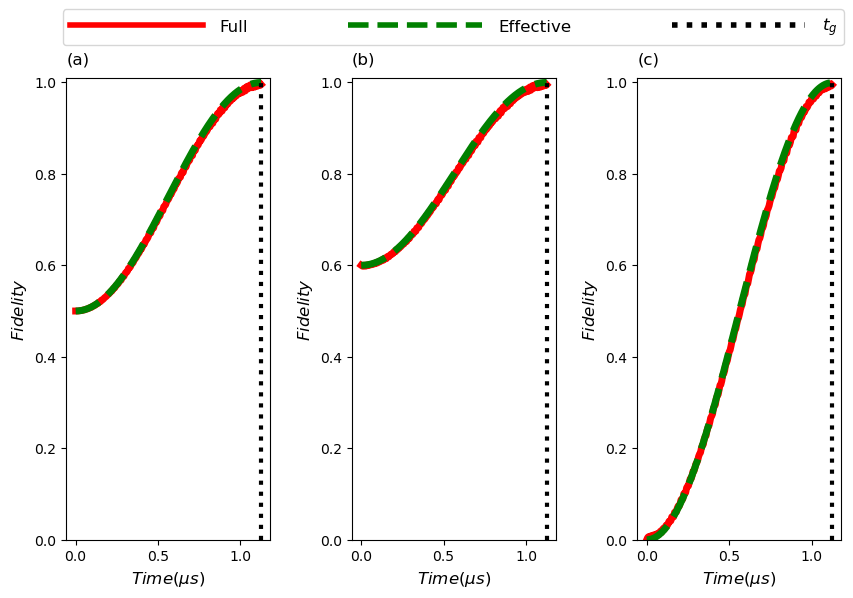

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [6]:
# ========================================================================================================================================================================================
# 1. 保真度计算
# ========================================================================================================================================================================================
import re
from matplotlib import style
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from qutip import * # type: ignore #quantum tools in python
from IPython import *
from IPython.display import display, Math
# ============================================================
# 1.1参数设置
# ============================================================

Omega_a = 2 * np.pi * (20 / 3) # Rabi频率，单位MHz，转换为角频率(参考2016 S.L Su)
Omega_b = 1.2 * Omega_a # Rabi频率，单位MHz，转换为角频率(参考2016 S.L Su)
Delta_a = (15 / 2) * Omega_a #大失谐条件
Delta_b = - Delta_a * (Omega_b**2) / (Omega_a**2) #比例关系

V = 2 * Delta_a - (Omega_a**2) / (2 * Delta_a) - (Omega_b**2)/(2*(2*Delta_a-Delta_b)) #RII V应满足的关系(求解出来的)

gamma =1.5e-3 #1.5e-3 MHz(参考2016 S.L Su)
gamma_A = 2 * np.pi #2pi MHz(参考2016 S.L Su)

g = Omega_a**2 / (2 * Delta_a) #Heff中耦合强度g
t_g = 2 * np.pi * Delta_a / (Omega_a**2) #计算得到的CZ门实现时间

# ============================================================
# 1.2 基矢|ij>...|kl>定义，外积|ij><kl|定义
# ============================================================

N = 3
i0, i1, ir = 0, 1, 2

def ket(i, j):
    return tensor(basis(N, i), basis(N, j))

def P(i, j, k, l):
    return ket(i, j) * ket(k, l).dag()

# ============================================================
# 1.3 有效哈密顿量(论文中计算得到)
# ============================================================


def H_eff(g):
    H_eff = g * (P(i1,i1,ir,ir)+P(ir,ir,i1,i1))
    return H_eff

def H_full(Omega_a, Omega_b, Delta_a):
    Delta_b = - Delta_a * (Omega_b**2 / Omega_a**2)

    # H1 = (|01><0r| + |11><1r| + |10><r0| + |11><r1|)
    H1 = (
        P(i0, i1, i0, ir) + P(i1, i1, i1, ir)
      + P(i1, i0, ir, i0) + P(i1, i1, ir, i1)
    )

    # H2 = (|1r><rr| + |r1><rr|)
    H2 = P(i1, ir, ir, ir) + P(ir, i1, ir, ir)

    # 对应图片公式：H = (...)H1 + (...)H2 + H.c.
    H_td = [
        [(Omega_a / 2) * H1, lambda t, args: np.exp(1j * Delta_a * t)],
        [(Omega_b / 2) * H1, lambda t, args: np.exp(1j * Delta_b * t)],
        [(Omega_a / 2) * H2, lambda t, args: np.exp(1j * (Delta_a - V) * t)],
        [(Omega_b / 2) * H2, lambda t, args: np.exp(1j * (Delta_b - V) * t)],
        [(Omega_a / 2) * H1.dag(), lambda t, args: np.exp(-1j * Delta_a * t)],
        [(Omega_b / 2) * H1.dag(), lambda t, args: np.exp(-1j * Delta_b * t)],
        [(Omega_a / 2) * H2.dag(), lambda t, args: np.exp(-1j * (Delta_a - V) * t)],
        [(Omega_b / 2) * H2.dag(), lambda t, args: np.exp(-1j * (Delta_b - V) * t)],
    ]

    return H_td
# ============================================================
# 1.4 Lindblad 算符(查阅了Qutip文档后，按照其标准形式定义)
# ============================================================

c_ops = []

#原子1的Lindblad算符
c_ops += [
    np.sqrt(gamma)   * tensor(basis(N, i0) * basis(N, ir).dag(), qeye(N)),
    np.sqrt(gamma)   * tensor(basis(N, i1) * basis(N, ir).dag(), qeye(N)),

]

#原子2的Lindblad算符
c_ops += [
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i0) * basis(N, ir).dag()),
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i1) * basis(N, ir).dag()),

]

def cz(state):
    # 理想CZ: |00>,|01>,|10>不变, |11> -> -|11>
    return   (
        (ket(i0, i0).dag() * state) * ket(i0, i0)
      + (ket(i0, i1).dag() * state) * ket(i0, i1)
      + (ket(i1, i0).dag() * state) * ket(i1, i0)
      - (ket(i1, i1).dag() * state) * ket(i1, i1)
    )

# ============================================================
# 1.6  保真度随时间变化的函数定义
# ============================================================
# 主要计算由qutip库内置函数fidelity完成
def state_fidelity_vs_time(H, psi0, psi_ideal, t_list, c_ops):
    result = mesolve(H, psi0, t_list, c_ops, [])
    return [fidelity(psi_ideal, rho) for rho in result.states]


# ============================================================
# 1.7 初始态分量系数对应a,b,c三图
# ============================================================

initial_states = [
    (0.5, 0.5, 0.5, 0.5),
    (np.sqrt(0.1), np.sqrt(0.3), np.sqrt(0.4), np.sqrt(0.2)),
    (np.sqrt(0.4),np.sqrt(0.1), 0, np.sqrt(0.5)),
]

# ============================================================
# 1.8 演化时间轴
# ============================================================

t_list = np.linspace(0, t_g, 201)

# ============================================================
# 1.9 作图
# ============================================================

# 创建一个1行3列的子图，用于分别绘制三种初始态下的保真度演化
fig, axes = plt.subplots(1, 3, figsize=(10,6))
# 遍历三组初始态参数，分别计算并绘制每种初始态下的保真度演化
for idx, (a, b, c, d) in enumerate(initial_states): # a,b,c,d为初始态分量系数

    # 构造初始态并归一化
    psi0 = (a*ket(0,0) + b*ket(0,1) + c*ket(1,0) + d*ket(1,1)).unit()
    # 计算理想CZ门作用下的目标态，即调用cz(state)函数
    psi_ideal = cz(psi0)
# 1).有效H_eff下计算每个时刻的保真度，并绘制保真度随时间的演化曲线
    fidelity_eff = state_fidelity_vs_time(H_eff(g), psi0, psi_ideal, t_list, c_ops)
   # 2).总哈密顿量H_full情况下的计算每个时刻的保真度，并绘制保真度随时间的演化曲线
    fidelity_full = state_fidelity_vs_time(H_full(Omega_a, Omega_b, Delta_a), psi0, psi_ideal, t_list, c_ops)
     # 绘制当前初始态下的保真度曲线
    ax = axes[idx]
    ax.plot(t_list, fidelity_full, 'r-', lw=5)  # H_full
    ax.plot(t_list, fidelity_eff, 'g--', lw=5)  # H_eff
    ax.axvline(t_g, color='k', ls=':', lw=3)  # 门操作时间的竖线
    # 设置子图标题，显示初始态信息
    ax.set_title(
        "(%s)"%(chr(97+idx)),
        loc='left',
        pad=10,
        fontsize=12,
    )
    
    ax.set_xlabel(r"$Time (\mu s)$",fontsize=12)  # 横坐标标签
    ax.set_ylabel(r"$Fidelity$",fontsize=12)   # 纵坐标标签
    ax.set_ylim(0, 1.01)        # 保真度范围
    

proxy_artists = [
    Line2D([0], [0], color='red', linestyle='-', linewidth=4, label='Full'),
    Line2D([0], [0], color='green', linestyle='--', linewidth=4, label='Effective'),
    Line2D([0], [0], color='black', linestyle=':', linewidth=4, label=r'$t_g$')
]


fig.legend(
    handles=proxy_artists, 
    bbox_to_anchor=(0.012, -0.02, 1,1),  # 与图形等宽
    loc='upper center',          # 锚点位置
    mode='none',                   # 默认模式
    ncol=3,                      # 3列
    borderaxespad=-0.5,           # 边框内边距
    columnspacing=6,           # 列间距
    handlelength=8.0,            # 图例句柄长度
    handletextpad=1,           # 句柄与文本间距
    fontsize=12,
    fancybox=True
)
plt.subplots_adjust(wspace=0.4)
plt.savefig('D:\\虚拟c盘\\Papers\\李艺恒毕业论文\\毕业论文数值模拟图\\1.eps')
plt.savefig('D:\\虚拟c盘\\Papers\\李艺恒毕业论文\\毕业论文数值模拟图\\1.pdf')
plt.savefig('D:\\虚拟c盘\\Papers\\李艺恒毕业论文\\毕业论文数值模拟图\\1.svg')
plt.show()

# 输出每种初始态在门操作时间 t_g 时的保真度（有耗散）
display(Math(r"\text{Fidelity at gate time } t_g \text{ (Effective):}"))
for idx, (a, b, c, d) in enumerate(initial_states):
    psi0 = (a*ket(0,0) + b*ket(0,1) + c*ket(1,0) + d*ket(1,1)).unit()
    psi_ideal = cz(psi0)
    result = mesolve(H_eff(g), psi0, t_list, c_ops)
    F = fidelity(psi_ideal, result.states[-1])
    display(Math(fr"({chr(97+idx)})\quad F(t_g) = {F:.6f}"))


display(Math(r"\text{Fidelity at gate time } t_g \text{ (Full):}"))
for idx, (a, b, c, d) in enumerate(initial_states):
    psi0 = (a*ket(0,0) + b*ket(0,1) + c*ket(1,0) + d*ket(1,1)).unit()
    psi_ideal = cz(psi0)
    result = mesolve(H_full(Omega_a, Omega_b, Delta_a), psi0, t_list, c_ops)
    F = fidelity(psi_ideal, result.states[-1])
    display(Math(fr"({chr(97+idx)})\quad F(t_g) = {F:.6f}"))